In [2]:
%pip install pandas numpy seaborn matplotlib


  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 4.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/11.3 MB 4.2 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.3 MB 3.7 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/11.3 MB 3.9 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.3 MB 4.1 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.3 MB 4.0 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.3 MB 3.9 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.3 MB 3.9 MB/s eta 0:00:02
   -------------------- ------------------- 

In [3]:
import pandas as pd 
import numpy as np             
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv(r"C:\Users\eshan\Downloads\archive (3)\StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
df.shape

(1000, 8)

In [ ]:
#CHecking for null values
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [15]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [16]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [18]:
print("Categories in the dataset:")
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())

Categories in the dataset:

gender:
['female' 'male']

race/ethnicity:
['group B' 'group C' 'group A' 'group D' 'group E']

parental level of education:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

lunch:
['standard' 'free/reduced']

test preparation course:
['none' 'completed']

math score:
[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]

reading score:
[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]

w

In [19]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numeric features: ['math score', 'reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [20]:
# Create total score
df['total score'] = df['math score'] + df['reading score'] + df['writing score']

# Create average score
df['average score'] = df['total score'] / 3

# Display first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [25]:
reading_less_20=df[df['reading score'] < 20]['average score'].count()
print(f"Number of students with reading score less than 20: {reading_less_20}")
writing_less_20=df[df['writing score'] < 20]['average score'].count()
print(f"Number of students with writing score less than 20: {writing_less_20}")
Math_less_20=df[df['math score'] < 20]['average score'].count()
print(f"Number of students with math score less than 20: {Math_less_20}")

Number of students with reading score less than 20: 1
Number of students with writing score less than 20: 3
Number of students with math score less than 20: 4


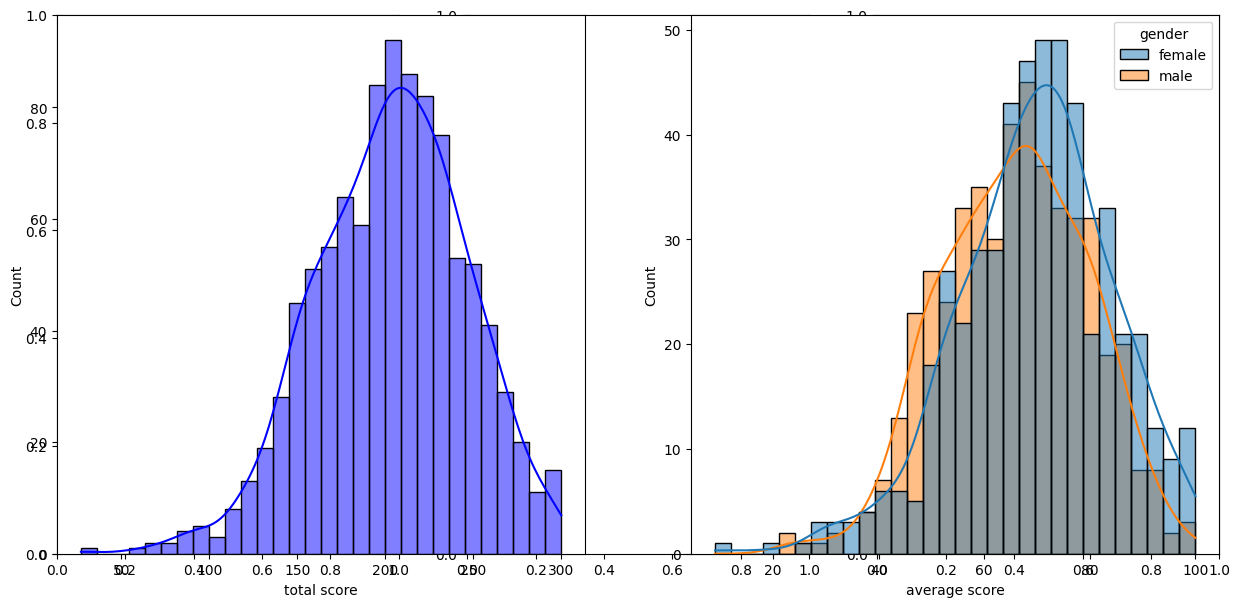

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score', kde=True, bins=30,color='blue')
plt.subplot(122)
sns.histplot(data=df,x='average score', kde=True, bins=30,color='orange',hue='gender')
plt.show()

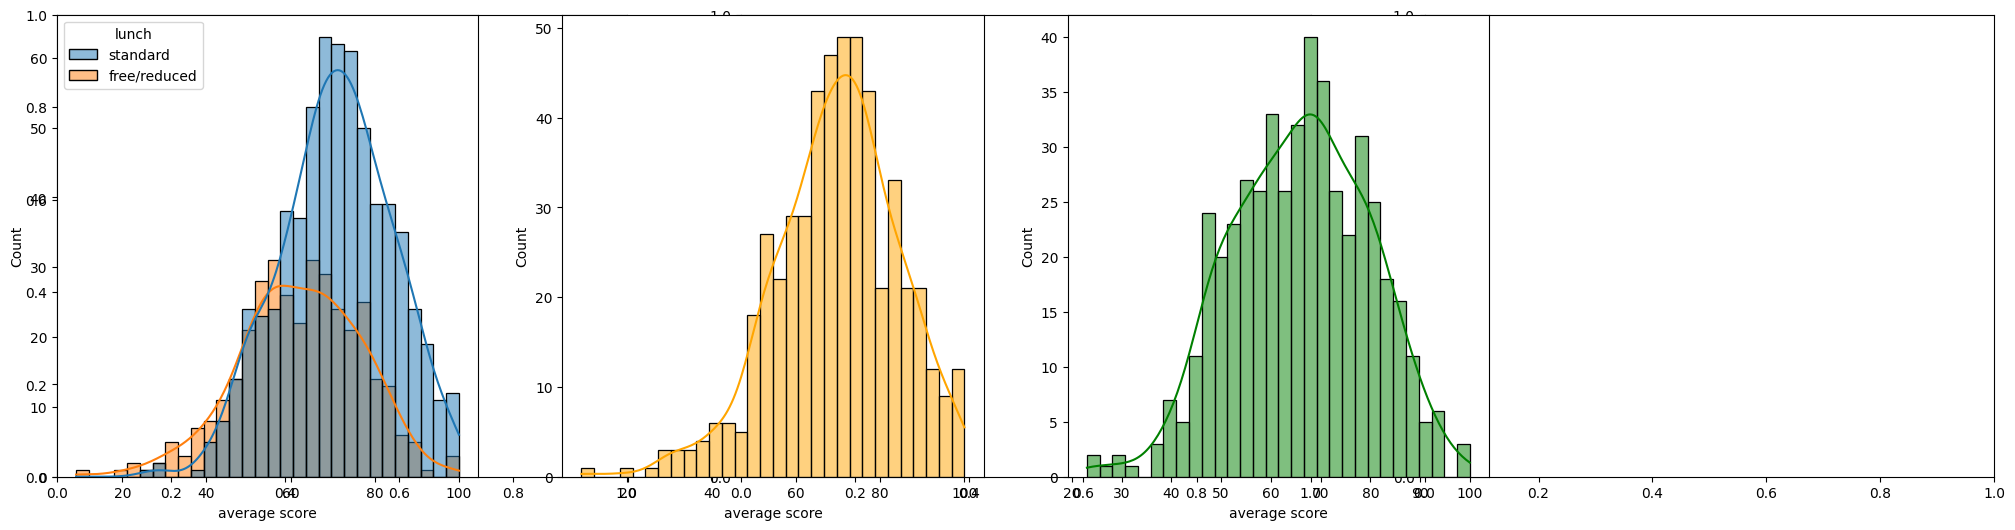

In [28]:
plt.subplots(1,3,figsize=(25, 6))
plt.subplot(141)
sns.histplot(data=df,x='average score', kde=True, bins=30,color='blue',hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average score', kde=True, bins=30,color='orange')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average score', kde=True, bins=30,color='green')
plt.show()